## 📥 Импорт данных и первичная подготовка

На этом этапе:
- Загружается Excel-файл с данными по производству, импорту и экспорту товаров Казахстана.
- Производится переименование колонок для удобства (`Import`, `Export`, `Industry`, `Company_Count` и т.д.).
- Выполняется удаление пустых строк и лишних пробелов в названиях.
- Логарифмируются числовые признаки (например, `Import_log`, `Industry_log`), чтобы нормализовать распределения и сделать признаки пригодными для кластеризации.


In [38]:
import os
os.environ["OMP_NUM_THREADS"] = "1"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


In [40]:
file_path = r"C:\Users\cheen\OneDrive\Desktop\new_sector\data_python_analyze.xlsx"

df = pd.read_excel(file_path)  # либо pd.read_excel(file_path, sheet_name='final') если требуется

print("Первые 5 строк исходных данных:")
print(df.head(5))

initial_shape = df.shape
df.dropna(inplace=True)  # удаляем строки с пустыми значениями (если такие имеются)
print(f"\nРазмер таблицы до очистки: {initial_shape}, после очистки: {df.shape}")

for col in ['Prom', 'oked', 'Product']:
    if col in df.columns and df[col].dtype == object:
        df[col] = df[col].str.strip()

print("\nИнформация о колонках и типах данных:")
print(df.info())


Первые 5 строк исходных данных:
                       Prom                                       oked  \
0   НЕФТЕХИМИЧЕСКАЯ ОТРАСЛЬ                         Добыча сырой нефти   
1  МЕТАЛЛУРГИЧЕСКАЯ ОТРАСЛЬ               Переработка ядерного топлива   
2  МЕТАЛЛУРГИЧЕСКАЯ ОТРАСЛЬ         Добыча руд других цветных металлов   
3  МЕТАЛЛУРГИЧЕСКАЯ ОТРАСЛЬ                          Производство меди   
4  МЕТАЛЛУРГИЧЕСКАЯ ОТРАСЛЬ  Производство чугуна, стали и ферросплавов   

                                             Product  Row Labels  \
0  Газовый конденсат стабильный плотностью при 20...      270900   
1        Уран природный необработанный; отходы и лом      284410   
2                          Руды и концентраты медные      260300   
3  Катоды и секции катодов из меди рафинированной...      740311   
4  Феррохром, содержащий по массе более 4% и не б...      720241   

       Import $      Export $   Industry, $         Spros    Import, ton  \
0  1.073034e+07  4.231495e+10  0.00000

In [42]:
df.rename(columns={
    'Import price, $/ton': 'Import_Price',
    'Export price, $/ton': 'Export_Price',
    'company': 'Company_Count',
    'Industry, $': 'Industry',
    'Import $': 'Import',
    'Export $': 'Export',
    'Import, ton': 'Import_Weight',
    'Export, ton': 'Export_Weight'
}, inplace=True)


## 📊 Вычисление спроса и усиление признаков

🔸 Расчёт спроса производится по формуле:
> `Spros = Import + Industry - Export`

🔸 Также усиливаются значимые переменные:
- Импорт, экспорт, производство получают больший вес
- Количество компаний и импортная цена — меньший

Это позволяет модели сосредоточиться на макроэкономически значимых товарах.


## 🧪 Корреляционный анализ признаков

Построена матрица корреляций между основными признаками (`Spros`, `Import`, `Export`, `Industry`, `Company_Count`, `Import_Price`).

Цель:
- Убедиться, что признаки не дублируют друг друга
- Проверить, как спрос связан с импортом и производством

Было выявлено:
- Высокая обратная корреляция между экспортом и спросом
- Независимость количества компаний от ключевых факторов


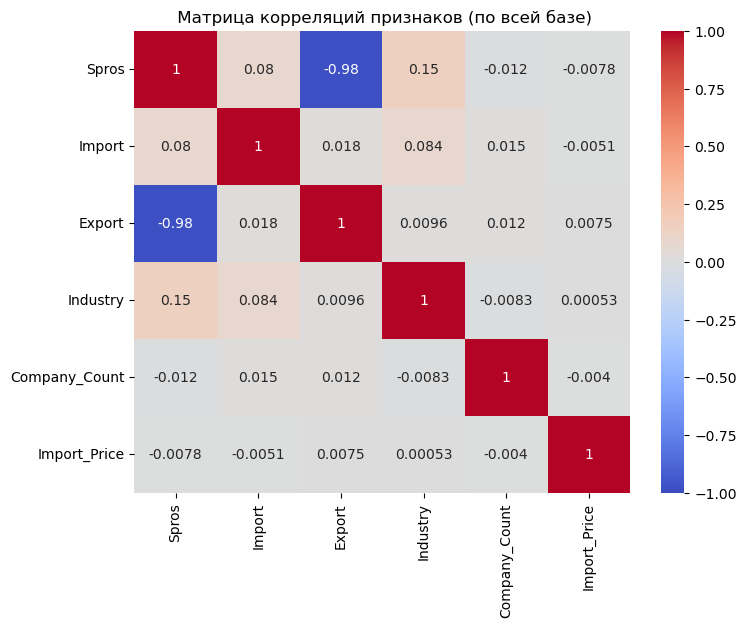

In [46]:
features_to_check = ['Spros', 'Import', 'Export', 'Industry', 'Company_Count', 'Import_Price']

corr = df[features_to_check].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title(" Матрица корреляций признаков (по всей базе)")
plt.show()


In [48]:
df['Spros'] = df['Import'] + df['Industry'] - df['Export']

df['Import_log'] = np.log1p(df['Import'].clip(lower=0))
df['Export_log'] = np.log1p(df['Export'].clip(lower=0))
df['Industry_log'] = np.log1p(df['Industry'].clip(lower=0))

df['Company_log'] = np.log1p(df['Company_Count'].clip(lower=0))
df['ImportPrice_log'] = np.log1p(df['Import_Price'].clip(lower=0))


In [50]:
df['X_import'] = df['Import_log'] * 0.45
df['X_export'] = df['Export_log'] * 0.25
df['X_industry'] = df['Industry_log'] * 0.25
df['X_company'] = df['Company_log'] * 0.03
df['X_price'] = df['ImportPrice_log'] * 0.02

## 🧩 Глобальная кластеризация всех товаров

С помощью алгоритма `KMeans` и метода главных компонент (PCA) проводится кластеризация всех товаров на основе логарифмированных и взвешенных признаков.

📍 Цель:
- Выделить группы товаров со схожими характеристиками по спросу, импорту, производству и насыщенности рынка.
- Понять общую структуру и наличие "скрытых" товарных ниш.

Результат визуализируется на 2D-графике.


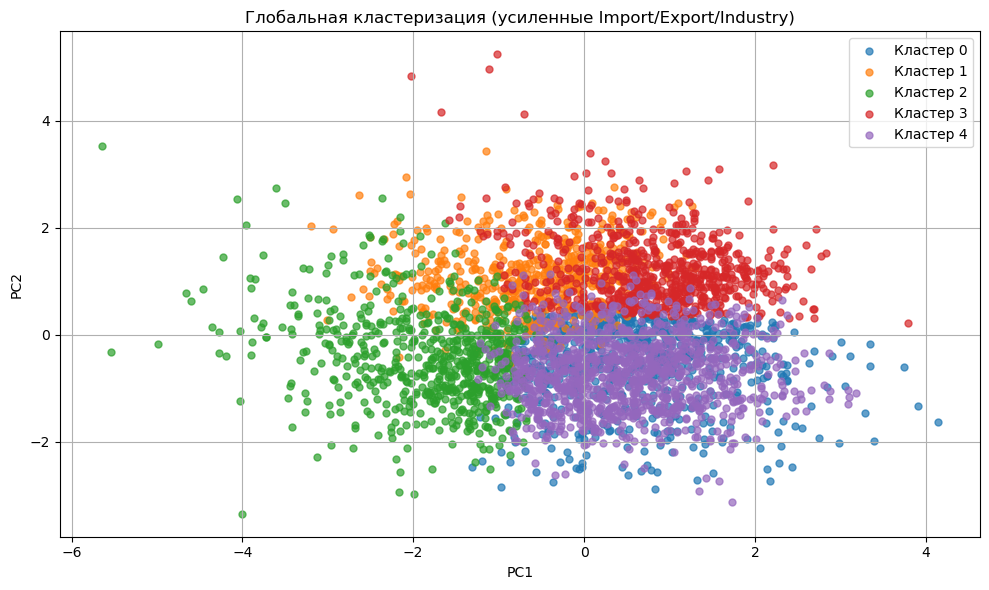

In [53]:
features_global = ['X_import', 'X_export', 'X_industry', 'X_company', 'X_price']
X_global = df[features_global].fillna(0)

scaler = StandardScaler()
X_scaled_global = scaler.fit_transform(X_global)

kmeans_global = KMeans(n_clusters=5, random_state=42, n_init=10)
df['Global_Cluster'] = kmeans_global.fit_predict(X_scaled_global)

pca_global = PCA(n_components=2)
X_pca_global = pca_global.fit_transform(X_scaled_global)

plt.figure(figsize=(10, 6))
for cl in sorted(df['Global_Cluster'].unique()):
    plt.scatter(X_pca_global[df['Global_Cluster'] == cl, 0],
                X_pca_global[df['Global_Cluster'] == cl, 1],
                label=f'Кластер {cl}', s=25, alpha=0.7)
plt.title("Глобальная кластеризация (усиленные Import/Export/Industry)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [55]:
cluster_summary = df.groupby('Global_Cluster')[[
    'Import', 'Export', 'Industry', 'Spros', 'Company_Count', 'Import_Price'
]].mean().round(2)

cluster_counts = df['Global_Cluster'].value_counts().sort_index()

print("📊 Средние значения по кластерам:\n")
display(cluster_summary)

print("\n📦 Количество товаров в каждом кластере:")
print(cluster_counts)


📊 Средние значения по кластерам:



,Import,Export,Industry,Spros,Company_Count,Import_Price
Global_Cluster,,,,,,
0,11932343.59,75209111.42,0.00,-63276767.83,703.22,6114.73
1,3759904.85,480018.20,960863.28,4240749.93,11.07,26830.21
2,229321.93,196881.15,122507.36,154948.14,163.15,22692812.16
3,47403508.39,14942663.11,9560953.89,42021799.17,81.27,5940610.69
4,12997167.64,10426127.03,16667780.19,19238820.80,111.90,10278.57



📦 Количество товаров в каждом кластере:
Global_Cluster
0     715
1     590
2     671
3     699
4    1128
Name: count, dtype: int64


### 📊 Сводка по глобальной кластеризации (на основе Import, Export, Industry)

| Кластер |     Import     |    Industry    |     Spros      | Company_Count |               Вывод                |
|:--------|:---------------|:---------------|:---------------|:---------------|:------------------------------------|
| **0**   | 🔺 большой      | ❗ **0**        | ❌ отрицательный | 🔥 много        | ❗ Исключить — перекос / мусор       |
| **1**   | 🟠 средний      | 🟡 средний      | ✅ умеренный     | 🔽 мало         | 💡 Под локализацию — слабо занят    |
| **2**   | 🔽 низкий       | 🔽 низкий       | 🔽 слабый        | 🟡 средне        | 🤔 Возможно нишевой                 |
| **3**   | 🔺 высокий      | 🔺 высокий      | ✅ большой       | 🔼 умеренно     | ⚖️ Почти сбалансирован — интересно  |
| **4**   | 🔥 очень высокий| 🔥 очень высокий| 🔥 максимум      | 🟡 средне        | 🔁 Уже насыщенный — нужен отбор     |


In [58]:
industry_list = df['Prom'].dropna().unique().tolist()
print(f"Найдено {len(industry_list)} отраслей:")
print(industry_list)

Найдено 11 отраслей:
['НЕФТЕХИМИЧЕСКАЯ ОТРАСЛЬ', 'МЕТАЛЛУРГИЧЕСКАЯ ОТРАСЛЬ', 'ДРУГИЕ ОТРАСЛИ', 'ПИЩЕВАЯ ПРОМЫШЛЕННОСТЬ', 'ХИМИЧЕСКАЯ ПРОМЫШЛЕННОСТЬ', 'МАШИНОСТРОИТЕЛЬНАЯ ОТРАСЛЬ', 'СТРОИТЕЛЬНЫЕ ТОВАРЫ', 'ТРАНСПОРТНЫЕ СРЕДСТВА', 'ДЕРЕВООБРАБАТЫВАЮЩАЯ И МЕБЕЛЬНАЯ ПРОМЫШЛЕННОСТЬ', 'ЛЕГКАЯ ПРОМЫШЛЕННОСТЬ', 'ФАРМАЦЕВТИЧЕСКАЯ ОТРАСЛЬ']


## 🏭 Кластеризация внутри каждой отрасли

Для каждой из 11 отраслей производится:
- Кластеризация товаров внутри отрасли (`KMeans + PCA`)
- Построение отдельных 2D-графиков
- Анализ средней ценности кластеров по показателям (спрос, импорт, компании)

Это позволяет:
- Глубоко анализировать внутриотраслевые различия
- Отделить устойчивые товары от тех, где есть потенциал для локализации



🔍 Анализ отрасли: НЕФТЕХИМИЧЕСКАЯ ОТРАСЛЬ


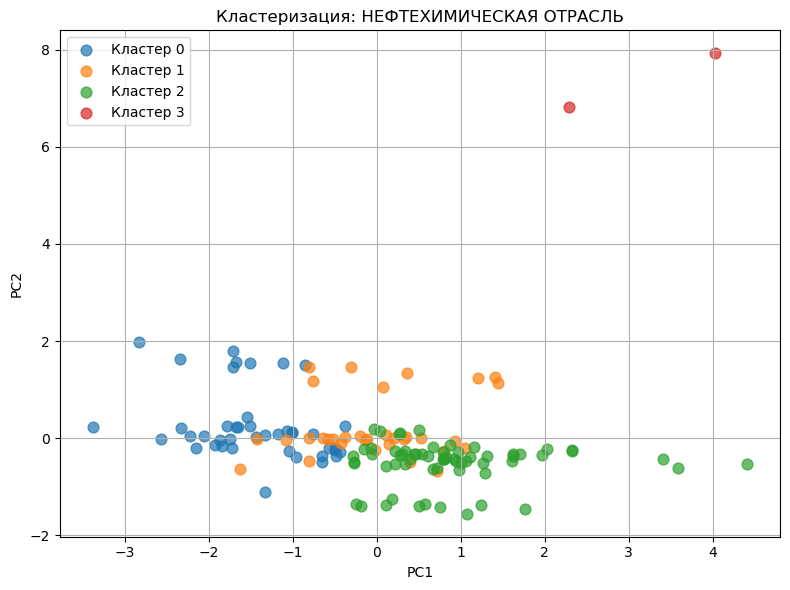

📊 Средние значения по кластерам:


,Import,Export,Industry,Spros,Company_Count
Cluster_Label,,,,,
0,1688174.90,6.553293e+04,0.00,1.622642e+06,174.90
1,34687755.63,5.912826e+06,0.00,2.877493e+07,121.91
2,35738126.48,6.891192e+08,0.00,-6.533811e+08,361.34
3,76557071.18,4.156392e+06,36330918.44,1.087316e+08,25.00



📝 Интерпретация кластеров (markdown):
```
| Кластер | Import      | Industry     | Spros        | Company_Count | Вывод                           |
|---------|-------------|--------------|--------------|----------------|---------------------------------|
|    0    | 🟡 средний | ❗ 0        | 🟡 средний | 🔥 много    | 💡 Нет производства — локализовать |
|    1    | 🔺 высокий  | ❗ 0        | 🔥 высокий  | 🔥 много    | 💡 Нет производства — локализовать |
|    2    | 🔺 высокий  | ❗ 0        | ❌ отриц.   | 🔥 много    | ⚠️ Перепроизводство / ошибка    |
|    3    | 🔺 высокий  | 🔺 высокий  | 🔥 высокий  | 🟡 умеренно | 🔥 Спрос > конкуренция           |

```

🔍 Анализ отрасли: МЕТАЛЛУРГИЧЕСКАЯ ОТРАСЛЬ


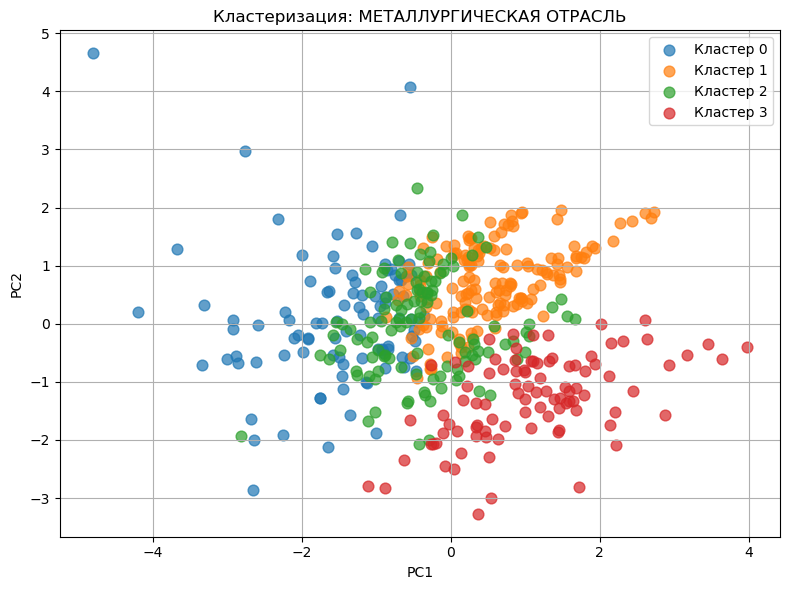

📊 Средние значения по кластерам:


,Import,Export,Industry,Spros,Company_Count
Cluster_Label,,,,,
0,1984022.67,49445350.37,71377424.74,23916097.04,76.17
1,16590144.26,54063261.58,61542192.68,24069075.36,77.29
2,6195085.29,1447762.25,15043.48,4762366.52,16.42
3,34542199.72,54709359.80,0.00,-20167160.08,412.26



📝 Интерпретация кластеров (markdown):
```
| Кластер | Import      | Industry     | Spros        | Company_Count | Вывод                           |
|---------|-------------|--------------|--------------|----------------|---------------------------------|
|    0    | 🟡 средний | 🔺 высокий  | 🔥 высокий  | 🟡 умеренно | 🤔 Требует анализа               |
|    1    | 🔺 высокий  | 🔺 высокий  | 🔥 высокий  | 🟡 умеренно | 🤔 Требует анализа               |
|    2    | 🟡 средний | 🔽 низкий  | 🟡 средний | 🔽 мало     | 🤔 Требует анализа               |
|    3    | 🔺 высокий  | ❗ 0        | ❌ отриц.   | 🔥 много    | ⚠️ Перепроизводство / ошибка    |

```

🔍 Анализ отрасли: ДРУГИЕ ОТРАСЛИ


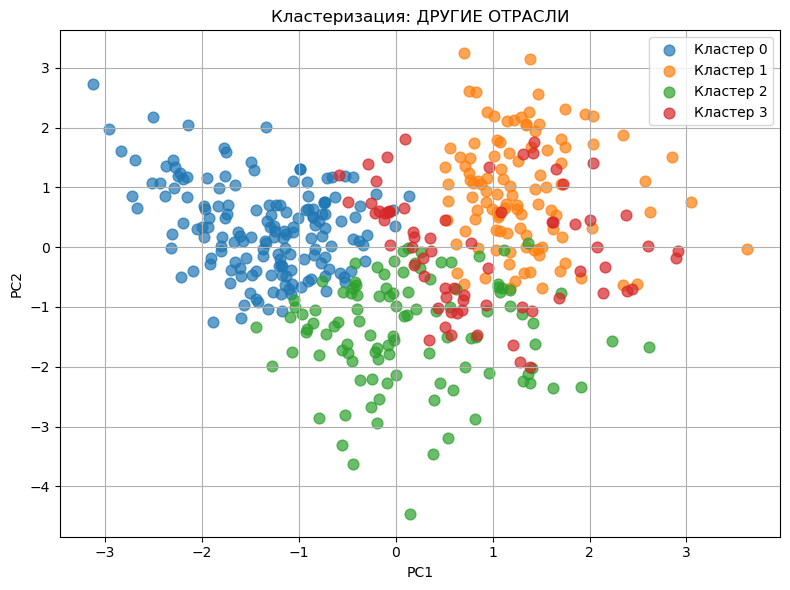

📊 Средние значения по кластерам:


,Import,Export,Industry,Spros,Company_Count
Cluster_Label,,,,,
0,9791803.98,26548300.68,0.00,-16756496.70,1754.88
1,11269231.67,962050.83,1156959.04,11464139.87,297.65
2,273938.44,97831.47,772.68,176879.65,1019.83
3,6175555.74,430503.29,5047.88,5750100.33,5.14



📝 Интерпретация кластеров (markdown):
```
| Кластер | Import      | Industry     | Spros        | Company_Count | Вывод                           |
|---------|-------------|--------------|--------------|----------------|---------------------------------|
|    0    | 🟡 средний | ❗ 0        | ❌ отриц.   | 🔥 много    | ⚠️ Перепроизводство / ошибка    |
|    1    | 🔺 высокий  | 🟡 средний | 🔥 высокий  | 🔥 много    | 🤔 Требует анализа               |
|    2    | 🔽 низкий  | 🔽 низкий  | 🔽 слабый  | 🔥 много    | 🤔 Требует анализа               |
|    3    | 🟡 средний | 🔽 низкий  | 🟡 средний | 🔽 мало     | 🤔 Требует анализа               |

```

🔍 Анализ отрасли: ПИЩЕВАЯ ПРОМЫШЛЕННОСТЬ


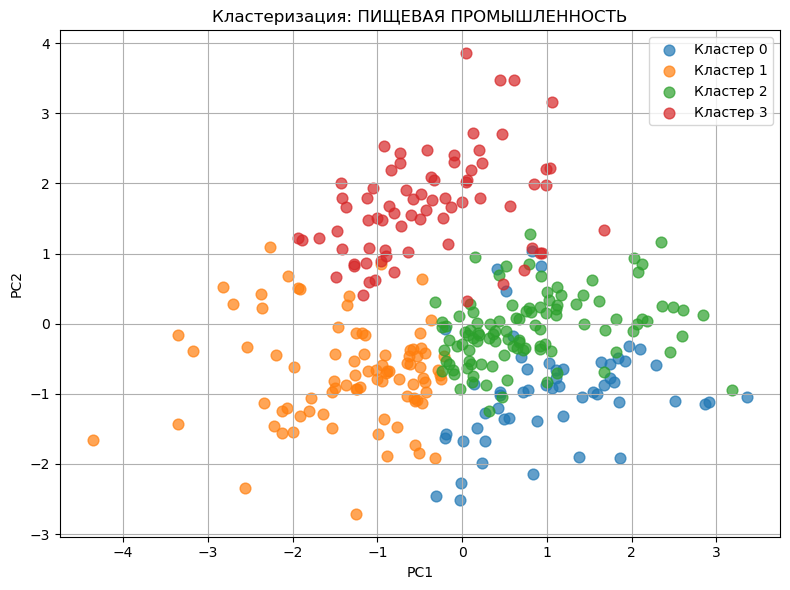

📊 Средние значения по кластерам:


,Import,Export,Industry,Spros,Company_Count
Cluster_Label,,,,,
0,9923856.05,2233540.78,7670975.23,15361290.51,23.14
1,353126.77,300379.90,354316.09,407062.96,212.51
2,17253640.69,9949618.97,30046928.69,37350950.41,159.52
3,24605792.03,15994700.47,0.00,8611091.56,401.34



📝 Интерпретация кластеров (markdown):
```
| Кластер | Import      | Industry     | Spros        | Company_Count | Вывод                           |
|---------|-------------|--------------|--------------|----------------|---------------------------------|
|    0    | 🟡 средний | 🟡 средний | 🔥 высокий  | 🟡 умеренно | 🔥 Спрос > конкуренция           |
|    1    | 🔽 низкий  | 🔽 низкий  | 🔽 слабый  | 🔥 много    | 🤔 Требует анализа               |
|    2    | 🔺 высокий  | 🔺 высокий  | 🔥 высокий  | 🔥 много    | 🤔 Требует анализа               |
|    3    | 🔺 высокий  | ❗ 0        | 🟡 средний | 🔥 много    | 💡 Нет производства — локализовать |

```

🔍 Анализ отрасли: ХИМИЧЕСКАЯ ПРОМЫШЛЕННОСТЬ


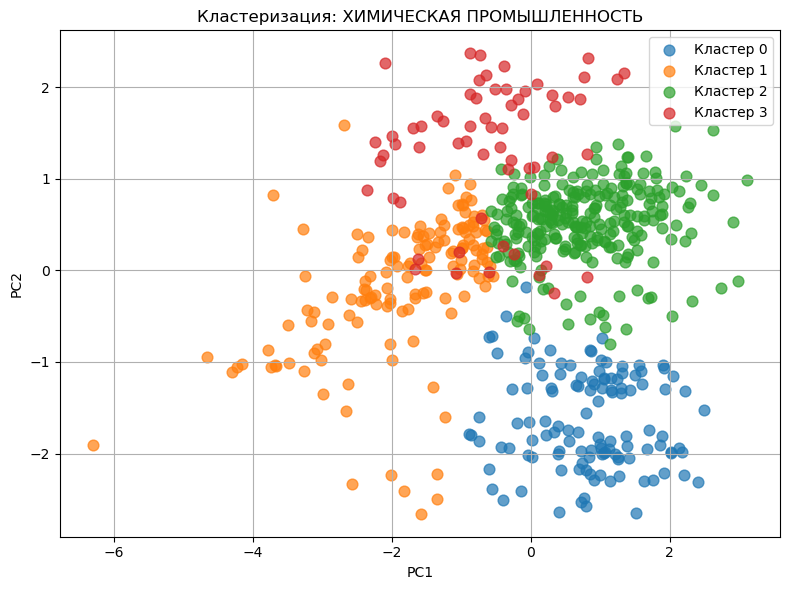

📊 Средние значения по кластерам:


,Import,Export,Industry,Spros,Company_Count
Cluster_Label,,,,,
0,14527310.57,3339594.46,0.00,11187716.11,170.90
1,79718.75,118105.32,44665.50,6278.93,71.90
2,9630882.77,4443731.35,6006089.06,11193240.48,84.40
3,3864821.25,2366878.27,2105962.13,3603905.11,7.71



📝 Интерпретация кластеров (markdown):
```
| Кластер | Import      | Industry     | Spros        | Company_Count | Вывод                           |
|---------|-------------|--------------|--------------|----------------|---------------------------------|
|    0    | 🔺 высокий  | ❗ 0        | 🔥 высокий  | 🔥 много    | 💡 Нет производства — локализовать |
|    1    | 🔽 низкий  | 🔽 низкий  | 🔽 слабый  | 🟡 умеренно | 🤔 Требует анализа               |
|    2    | 🟡 средний | 🟡 средний | 🔥 высокий  | 🟡 умеренно | 🤔 Требует анализа               |
|    3    | 🟡 средний | 🟡 средний | 🟡 средний | 🔽 мало     | 🤔 Требует анализа               |

```

🔍 Анализ отрасли: МАШИНОСТРОИТЕЛЬНАЯ ОТРАСЛЬ


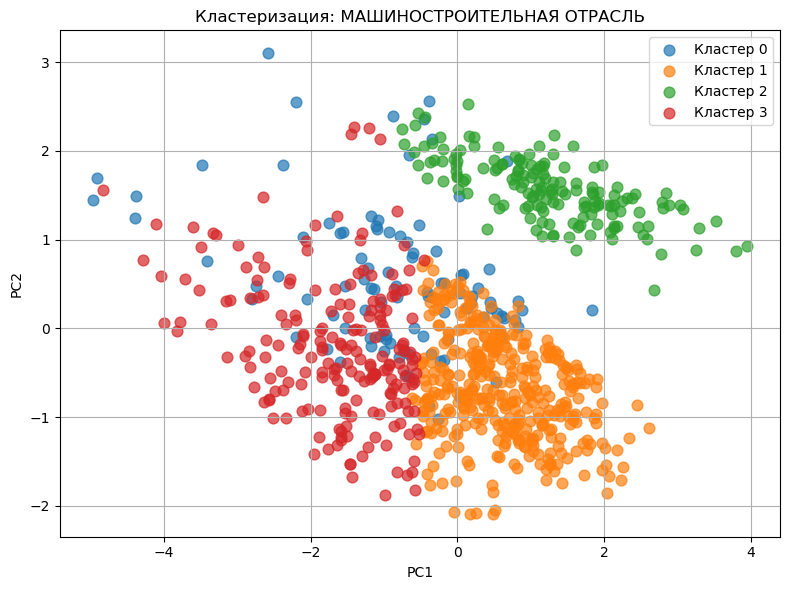

📊 Средние значения по кластерам:


,Import,Export,Industry,Spros,Company_Count
Cluster_Label,,,,,
0,4108914.83,791210.39,4929.56,3322633.99,44.52
1,25967374.70,5084480.11,0.00,20882894.59,59.37
2,36523521.66,5827327.97,4957979.75,35654173.44,81.61
3,1610516.02,122290.82,446.34,1488671.54,27.87



📝 Интерпретация кластеров (markdown):
```
| Кластер | Import      | Industry     | Spros        | Company_Count | Вывод                           |
|---------|-------------|--------------|--------------|----------------|---------------------------------|
|    0    | 🟡 средний | 🔽 низкий  | 🟡 средний | 🟡 умеренно | 🤔 Требует анализа               |
|    1    | 🔺 высокий  | ❗ 0        | 🔥 высокий  | 🟡 умеренно | 💡 Нет производства — локализовать |
|    2    | 🔺 высокий  | 🟡 средний | 🔥 высокий  | 🟡 умеренно | 🤔 Требует анализа               |
|    3    | 🟡 средний | 🔽 низкий  | 🟡 средний | 🟡 умеренно | 🤔 Требует анализа               |

```

🔍 Анализ отрасли: СТРОИТЕЛЬНЫЕ ТОВАРЫ


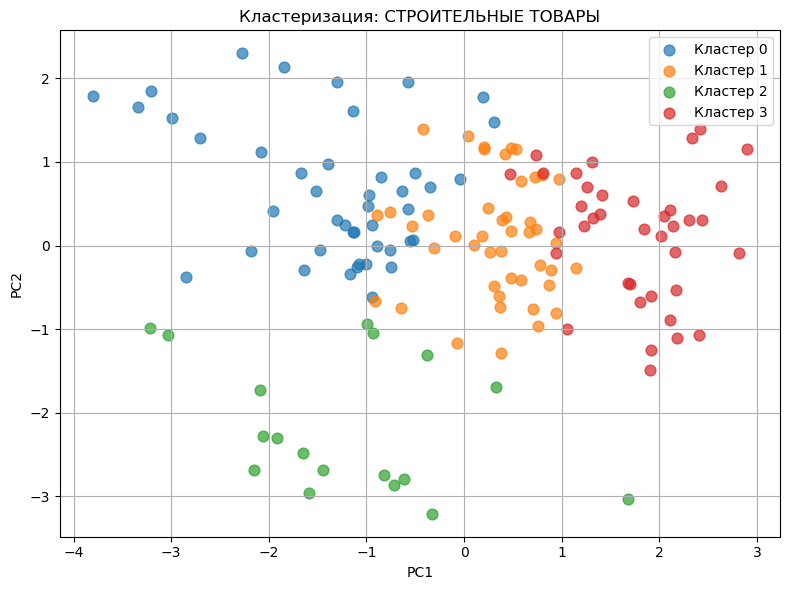

📊 Средние значения по кластерам:


,Import,Export,Industry,Spros,Company_Count
Cluster_Label,,,,,
0,1054072.97,17981.54,514838.76,1550930.19,73.82
1,6078067.67,578255.51,3894006.69,9393818.86,89.80
2,9904702.66,4005807.79,1022.16,5899917.04,17.44
3,16288636.61,3775790.05,34896997.92,47409844.49,270.63



📝 Интерпретация кластеров (markdown):
```
| Кластер | Import      | Industry     | Spros        | Company_Count | Вывод                           |
|---------|-------------|--------------|--------------|----------------|---------------------------------|
|    0    | 🟡 средний | 🔽 низкий  | 🟡 средний | 🟡 умеренно | 🤔 Требует анализа               |
|    1    | 🟡 средний | 🟡 средний | 🟡 средний | 🟡 умеренно | 🤔 Требует анализа               |
|    2    | 🟡 средний | 🔽 низкий  | 🟡 средний | 🔽 мало     | 🤔 Требует анализа               |
|    3    | 🔺 высокий  | 🔺 высокий  | 🔥 высокий  | 🔥 много    | 🤔 Требует анализа               |

```

🔍 Анализ отрасли: ТРАНСПОРТНЫЕ СРЕДСТВА


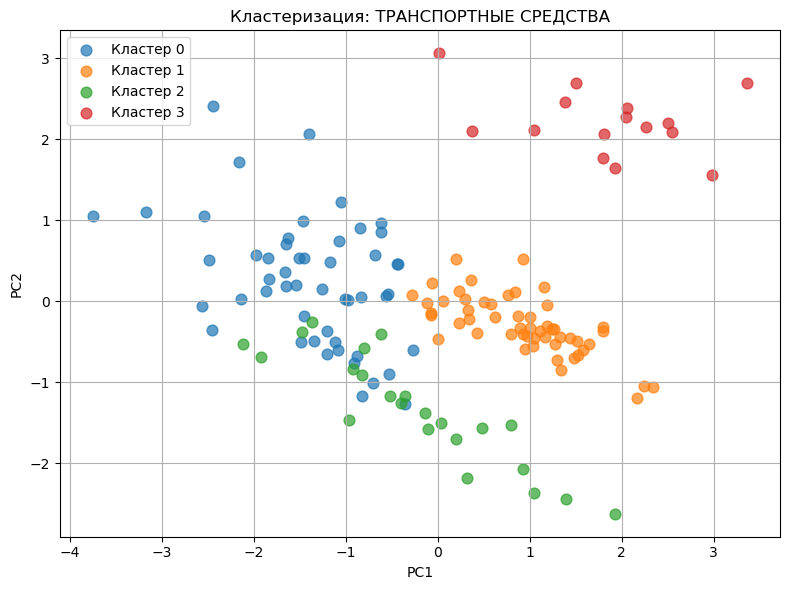

📊 Средние значения по кластерам:


,Import,Export,Industry,Spros,Company_Count
Cluster_Label,,,,,
0,4.355648e+06,720336.56,0.00,3.635312e+06,14.12
1,1.442805e+08,9294331.89,0.00,1.349862e+08,38.28
2,5.212062e+07,9111456.73,0.00,4.300916e+07,30.35
3,4.643371e+07,10588604.78,58278300.32,9.412341e+07,55.00



📝 Интерпретация кластеров (markdown):
```
| Кластер | Import      | Industry     | Spros        | Company_Count | Вывод                           |
|---------|-------------|--------------|--------------|----------------|---------------------------------|
|    0    | 🟡 средний | ❗ 0        | 🟡 средний | 🔽 мало     | 💡 Нет производства — локализовать |
|    1    | 🔺 высокий  | ❗ 0        | 🔥 высокий  | 🟡 умеренно | 💡 Нет производства — локализовать |
|    2    | 🔺 высокий  | ❗ 0        | 🔥 высокий  | 🟡 умеренно | 💡 Нет производства — локализовать |
|    3    | 🔺 высокий  | 🔺 высокий  | 🔥 высокий  | 🟡 умеренно | 🤔 Требует анализа               |

```

🔍 Анализ отрасли: ДЕРЕВООБРАБАТЫВАЮЩАЯ И МЕБЕЛЬНАЯ ПРОМЫШЛЕННОСТЬ


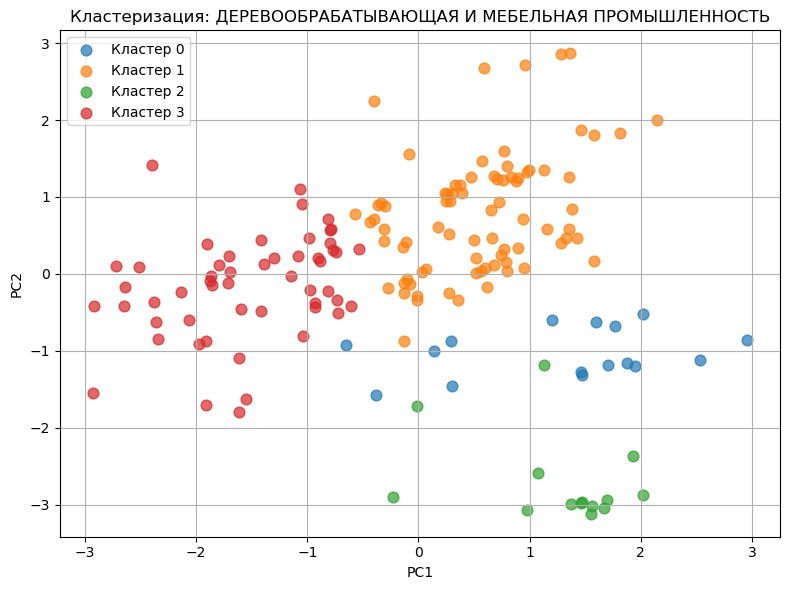

📊 Средние значения по кластерам:


,Import,Export,Industry,Spros,Company_Count
Cluster_Label,,,,,
0,30525212.64,7772848.63,441.37,22752805.38,84.75
1,12711161.03,1149771.60,4414590.79,15975980.22,173.70
2,14798604.36,425215.47,1350.15,14374739.04,0.71
3,627521.09,25547.27,80730.25,682704.07,113.04



📝 Интерпретация кластеров (markdown):
```
| Кластер | Import      | Industry     | Spros        | Company_Count | Вывод                           |
|---------|-------------|--------------|--------------|----------------|---------------------------------|
|    0    | 🔺 высокий  | 🔽 низкий  | 🔥 высокий  | 🟡 умеренно | 📦 Импортозамещение              |
|    1    | 🔺 высокий  | 🟡 средний | 🔥 высокий  | 🔥 много    | 🤔 Требует анализа               |
|    2    | 🔺 высокий  | 🔽 низкий  | 🔥 высокий  | 🔽 мало     | 🔥 Спрос > конкуренция           |
|    3    | 🔽 низкий  | 🔽 низкий  | 🔽 слабый  | 🔥 много    | 🤔 Требует анализа               |

```

🔍 Анализ отрасли: ЛЕГКАЯ ПРОМЫШЛЕННОСТЬ


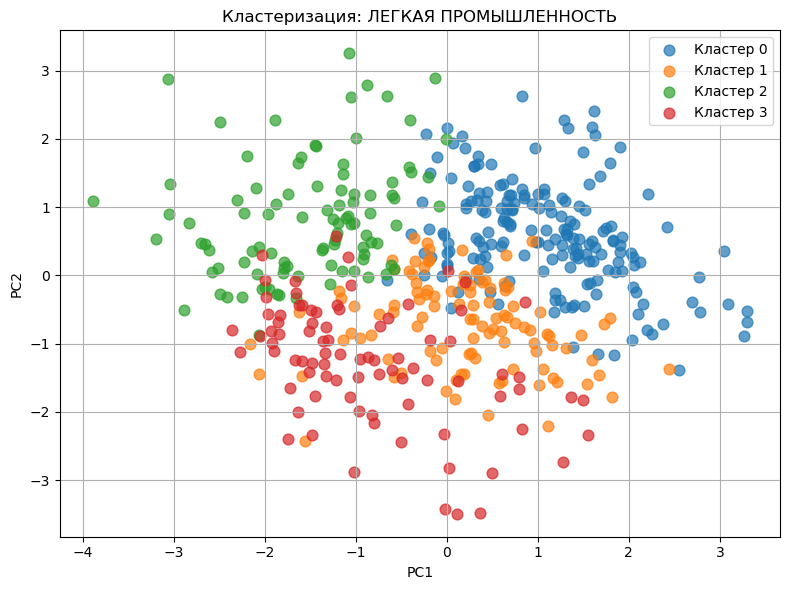

📊 Средние значения по кластерам:


,Import,Export,Industry,Spros,Company_Count
Cluster_Label,,,,,
0,16220399.34,572037.72,0.00,15648361.62,267.00
1,14043132.14,353797.22,0.00,13689334.92,24.88
2,214674.38,4319.37,1339.54,211694.55,71.77
3,10011101.51,442498.46,865197.31,10433800.37,63.00



📝 Интерпретация кластеров (markdown):
```
| Кластер | Import      | Industry     | Spros        | Company_Count | Вывод                           |
|---------|-------------|--------------|--------------|----------------|---------------------------------|
|    0    | 🔺 высокий  | ❗ 0        | 🔥 высокий  | 🔥 много    | 💡 Нет производства — локализовать |
|    1    | 🔺 высокий  | ❗ 0        | 🔥 высокий  | 🟡 умеренно | 💡 Нет производства — локализовать |
|    2    | 🔽 низкий  | 🔽 низкий  | 🔽 слабый  | 🟡 умеренно | 🤔 Требует анализа               |
|    3    | 🔺 высокий  | 🔽 низкий  | 🔥 высокий  | 🟡 умеренно | 📦 Импортозамещение              |

```

🔍 Анализ отрасли: ФАРМАЦЕВТИЧЕСКАЯ ОТРАСЛЬ


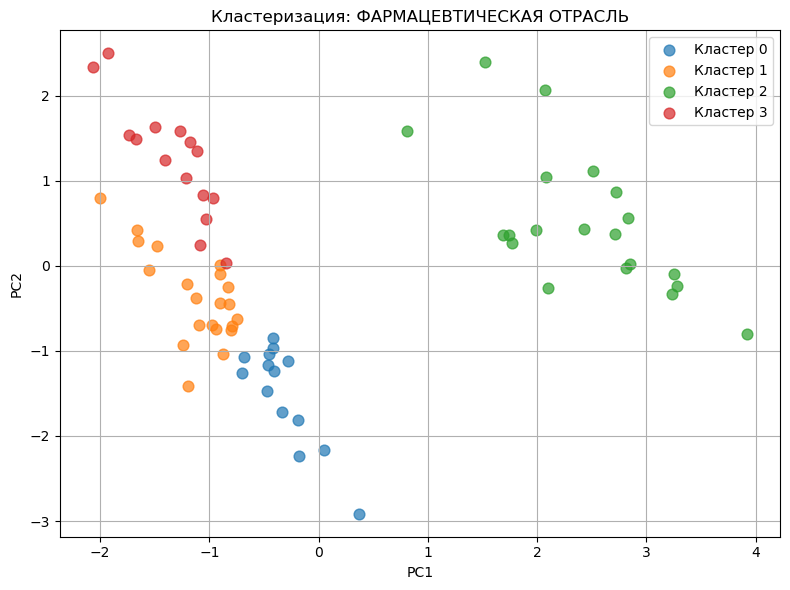

📊 Средние значения по кластерам:


,Import,Export,Industry,Spros,Company_Count
Cluster_Label,,,,,
0,3548108.55,269176.10,692211.36,3971143.81,63.0
1,257595.75,4961.06,50255.14,302889.83,63.0
2,87458599.61,2457216.94,0.00,85001382.68,221.0
3,230634.71,3002.80,44995.23,272627.15,63.0



📝 Интерпретация кластеров (markdown):
```
| Кластер | Import      | Industry     | Spros        | Company_Count | Вывод                           |
|---------|-------------|--------------|--------------|----------------|---------------------------------|
|    0    | 🟡 средний | 🔽 низкий  | 🟡 средний | 🟡 умеренно | 🤔 Требует анализа               |
|    1    | 🔽 низкий  | 🔽 низкий  | 🔽 слабый  | 🟡 умеренно | 🤔 Требует анализа               |
|    2    | 🔺 высокий  | ❗ 0        | 🔥 высокий  | 🔥 много    | 💡 Нет производства — локализовать |
|    3    | 🔽 низкий  | 🔽 низкий  | 🔽 слабый  | 🟡 умеренно | 🤔 Требует анализа               |

```


In [61]:
results_by_industry = {}

for prom in industry_list:
    print(f"\n🔍 Анализ отрасли: {prom}")
    
    try:
        df_sub = df[df['Prom'] == prom].copy()

        if len(df_sub) < 4:
            print("⚠️ Недостаточно данных для кластеризации, пропущено.")
            continue

        df_sub['X_import']   = df_sub['Import_log'] * 0.45
        df_sub['X_export']   = df_sub['Export_log'] * 0.25
        df_sub['X_industry'] = df_sub['Industry_log'] * 0.25
        df_sub['X_company']  = df_sub['Company_log'] * 0.03
        df_sub['X_price']    = df_sub['ImportPrice_log'] * 0.02

        features = ['X_import', 'X_export', 'X_industry', 'X_company', 'X_price']
        X = df_sub[features].fillna(0)

        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)

        kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
        df_sub['Cluster_Label'] = kmeans.fit_predict(X_scaled)

        # PCA
        pca = PCA(n_components=2)
        X_pca = pca.fit_transform(X_scaled)

        # 📈 График кластеров
        plt.figure(figsize=(8,6))
        for cluster in sorted(df_sub['Cluster_Label'].unique()):
            plt.scatter(X_pca[df_sub['Cluster_Label'] == cluster, 0],
                        X_pca[df_sub['Cluster_Label'] == cluster, 1],
                        label=f'Кластер {cluster}', s=60, alpha=0.7)
        plt.title(f"Кластеризация: {prom}")
        plt.xlabel("PC1")
        plt.ylabel("PC2")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

        cluster_summary = df_sub.groupby('Cluster_Label')[[
            'Import', 'Export', 'Industry', 'Spros', 'Company_Count'
        ]].mean().round(2)

        print("📊 Средние значения по кластерам:")
        display(cluster_summary)

        print("\n📝 Интерпретация кластеров (markdown):")

        def eval_level(val):
            if val == 0: return "❗ 0       "
            elif val < 1e6: return "🔽 низкий "
            elif val < 1e7: return "🟡 средний"
            else: return "🔺 высокий "

        def eval_spros(val):
            if val < 0: return "❌ отриц.  "
            elif val < 1e6: return "🔽 слабый "
            elif val < 1e7: return "🟡 средний"
            else: return "🔥 высокий "

        def eval_comp(val):
            if val < 20: return "🔽 мало    "
            elif val < 100: return "🟡 умеренно"
            else: return "🔥 много   "

        markdown_table = "| Кластер | Import      | Industry     | Spros        | Company_Count | Вывод                           |\n"
        markdown_table += "|---------|-------------|--------------|--------------|----------------|---------------------------------|\n"

        for cl in cluster_summary.index:
            row = cluster_summary.loc[cl]
            imp, ind, spr, comp = row['Import'], row['Industry'], row['Spros'], row['Company_Count']

            if ind == 0 and spr > 1e6:
                conclusion = "💡 Нет производства — локализовать"
            elif spr < 0:
                conclusion = "⚠️ Перепроизводство / ошибка"
            elif spr > 1e7 and comp < 30:
                conclusion = "🔥 Спрос > конкуренция"
            elif imp > 1e7 and ind < 1e6:
                conclusion = "📦 Импортозамещение"
            else:
                conclusion = "🤔 Требует анализа"

            markdown_table += f"| {cl:^7} | {eval_level(imp)} | {eval_level(ind)} | {eval_spros(spr)} | {eval_comp(comp)} | {conclusion:<31} |\n"

        print("```")
        print(markdown_table)
        print("```")

        results_by_industry[prom] = df_sub

    except Exception as e:
        print(f"❌ Ошибка в {prom}: {e}")


## 🎯 Приоритизация товаров по логике DATAmetrics

Каждому товару присваивается приоритет на основе следующих условий:

- 🔴 Очень высокий — нет производства, высокий спрос и импорт, мало компаний
- 🔥 Стратегический — есть производство, но спрос и импорт огромные
- 🟠 Высокий — есть спрос, но рынок ещё не насыщен
- 🟡 / ⚪ / ❕ — менее критичные, но потенциально важные

Результат отображается с условным форматированием в виде цветной таблицы.


In [64]:
for prom, df_sub in results_by_industry.items():
    from IPython.display import display, Markdown
    
    display(Markdown(f"## 🏭 **ОТРАСЛЬ: {prom.upper()}**"))


    print("🔍 ЛОГИКА СОРТИРОВКИ:")
    print("- Сначала приоритет: 🔴, 🔥, 🟠 и т.д.")
    print("- Внутри приоритета: по убыванию спроса (Spros)")
    print("- Показаны все товары отрасли (не только топ)\n")

    print("📌 КРИТЕРИИ ПРИОРИТЕТОВ:")
    print("🔴 Нет производства, высокий спрос и импорт, мало компаний")
    print("🔥 Уже есть производство, но спрос и импорт — огромные")
    print("🟠 Высокий потенциал: есть спрос, но ещё не насыщено")
    print("🟡 / ⚪ / ❕ — менее критичные позиции, но интересны для анализа\n")

    df_i = df_sub.copy()

    def assign_priority(row):
        s = row['Spros']
        i = row['Import']
        ind = row['Industry']
        c = row['Company_Count']
        if ind == 0 and s > 1e7 and i > 1e7 and c < 30:
            return "🔴 Очень высокий"
        elif ind > 0 and s > 1e7 and i > 1e7 and c < 30:
            return "🔥 Стратегический (ядро)"
        elif s > 1e6 and i > 1e6 and c < 50:
            return "🟠 Высокий"
        elif s > 1e5 and i > 1e5:
            return "🟡 Средний"
        elif ind > 0 and s > 0 and c > 50:
            return "⚪ Устойчивый рынок"
        else:
            return "❕ На наблюдении"

    df_i['Priority'] = df_i.apply(assign_priority, axis=1)

    priority_order = [
        "🔴 Очень высокий", "🔥 Стратегический (ядро)", "🟠 Высокий",
        "🟡 Средний", "⚪ Устойчивый рынок", "❕ На наблюдении"
    ]
    df_i['Priority'] = pd.Categorical(df_i['Priority'], categories=priority_order, ordered=True)

    full_sorted = df_i.sort_values(by=['Priority', 'Spros'], ascending=[True, False])[
        ['Product', 'Spros', 'Import', 'Industry', 'Company_Count', 'Priority']
    ]

    def highlight_priority(val):
        color_map = {
            "🔴 Очень высокий": "background-color: #ffcccc;",
            "🔥 Стратегический (ядро)": "background-color: #ffd699;",
            "🟠 Высокий": "background-color: #ffffcc;",
            "🟡 Средний": "background-color: #ccf2ff;",
            "⚪ Устойчивый рынок": "background-color: #e6e6e6;",
            "❕ На наблюдении": "background-color: #f9f9f9;"
        }
        return color_map.get(val, "")

    styled = full_sorted.style.map(highlight_priority, subset=['Priority'])\
                              .format({'Spros': '{:,.0f}', 'Import': '{:,.0f}',
                                       'Industry': '{:,.0f}', 'Company_Count': '{:,.0f}'})

    display(styled)


## 🏭 **ОТРАСЛЬ: НЕФТЕХИМИЧЕСКАЯ ОТРАСЛЬ**

🔍 ЛОГИКА СОРТИРОВКИ:
- Сначала приоритет: 🔴, 🔥, 🟠 и т.д.
- Внутри приоритета: по убыванию спроса (Spros)
- Показаны все товары отрасли (не только топ)

📌 КРИТЕРИИ ПРИОРИТЕТОВ:
🔴 Нет производства, высокий спрос и импорт, мало компаний
🔥 Уже есть производство, но спрос и импорт — огромные
🟠 Высокий потенциал: есть спрос, но ещё не насыщено
🟡 / ⚪ / ❕ — менее критичные позиции, но интересны для анализа



,Product,Spros,Import,Industry,Company_Count,Priority
5063,"Для легковых автомобилей (включая грузопассажирские автомобили-фургоны и спортивные автомобили), с посадочным диаметром менее 15 дюймов и с посадочным диаметром 15 дюймов или более, но не более 16 дюймов и прочие","231,886,712","236,551,192",0,22,🔴 Очень высокий
5031,"Шины для автобусов или моторных транспортных средств для перевозки грузов с индексом нагрузки не более 121, шины с цельнометаллическим кордом и прочие","178,333,205","190,224,009",0,22,🔴 Очень высокий
4972,"Шины и покрышки пневматические резиновые новые, для транспортных средств и машин, используемых в строительстве, горном деле или промышленности","109,469,004","180,010,841",0,22,🔴 Очень высокий
4625,"Шины и покрышки пневматические резиновые новые, для сельскохозяйственных или лесохозяйственных транспортных средств и машин","28,224,148","29,577,712",0,22,🔴 Очень высокий
5052,"Кокс и полукокс из каменного угля, агломерированные или неагломерированные для производства электродов","211,124,297","146,293,638","69,425,099",25,🔥 Стратегический (ядро)
4027,"Прочие трубы, трубки и шланги из вулканиз.резины, армированные или комбинир.иным способом только с металлом с фитингами для промышл.сборки моторн.трансп.ср-в тов.поз.8701-8705,их узлов и агрегатов","8,415,528","10,902,309",0,32,🟠 Высокий
3860,"Пек, полученный из каменноугольной смолы или прочих минеральных смол","6,338,899","6,820,504","3,236,738",25,🟠 Высокий
3646,"Шины и покрышки пневматические резиновые новые, прочие","4,534,440","4,598,415",0,22,🟠 Высокий
3319,"Шины и покрышки пневматические резиновые новые, для использования в авиации","2,849,514","6,055,282",0,22,🟠 Высокий
3258,Камеры резиновые: для легковых автомобилей (включая грузопассажирские автомобили-фургоны и спортивные автомобили),"2,643,859","3,509,433",0,22,🟠 Высокий


## 🏭 **ОТРАСЛЬ: МЕТАЛЛУРГИЧЕСКАЯ ОТРАСЛЬ**

🔍 ЛОГИКА СОРТИРОВКИ:
- Сначала приоритет: 🔴, 🔥, 🟠 и т.д.
- Внутри приоритета: по убыванию спроса (Spros)
- Показаны все товары отрасли (не только топ)

📌 КРИТЕРИИ ПРИОРИТЕТОВ:
🔴 Нет производства, высокий спрос и импорт, мало компаний
🔥 Уже есть производство, но спрос и импорт — огромные
🟠 Высокий потенциал: есть спрос, но ещё не насыщено
🟡 / ⚪ / ❕ — менее критичные позиции, но интересны для анализа



...

🔍 ЛОГИКА СОРТИРОВКИ:
- Сначала приоритет: 🔴, 🔥, 🟠 и т.д.
- Внутри приоритета: по убыванию спроса (Spros)
- Показаны все товары отрасли (не только топ)

📌 КРИТЕРИИ ПРИОРИТЕТОВ:
🔴 Нет производства, высокий спрос и импорт, мало компаний
🔥 Уже есть производство, но спрос и импорт — огромные
🟠 Высокий потенциал: есть спрос, но ещё не насыщено
🟡 / ⚪ / ❕ — менее критичные позиции, но интересны для анализа



,Product,Spros,Import,Industry,Company_Count,Priority
5058,"Блузки, блузы и блузоны женские или для девочек из хлопчатобумажной пряжи","223,383,924","223,537,869",0,15,🔴 Очень высокий
5026,"Майки, фуфайки с рукавами и прочие нательные фуфайки трикотажные, из хлопчатобумажной пряжи, машинного или ручного вязания","167,929,639","170,238,507",0,15,🔴 Очень высокий
4905,"Сумки дамские с плечевым ремнем или без него, включая сумки без ручек,с лицевой поверхностью из листов полимерных материалов","69,400,049","70,215,362",0,23,🔴 Очень высокий
4883,"Бюстгалтеры в наборе, состоящем из бюстгалтера и трусов, предназначенном для розничной продажи трикотажные машинного или ручного вязания","63,533,276","63,822,163",0,15,🔴 Очень высокий
4830,"Сумки дорожные, сумочки косметические, рюкзаки и спортивные сумки с лицевой поверхностью из листов полимерных материалов","52,685,002","54,962,308",0,23,🔴 Очень высокий
4779,"Прочие ворсовые, готовые ковры и прочие текстильные напольные покрытия, из химических текстильных материалов: аксминстерские ковры","44,692,244","46,855,250",0,10,🔴 Очень высокий
4768,Из шерстяной пряжи или пряжи из тонкого волоса животных или из химических нитей,"42,372,040","43,002,201",0,15,🔴 Очень высокий
4750,Рубашки мужские или для мальчиков из хлопчатобумажной пряжи,"40,011,309","40,188,899",0,15,🔴 Очень высокий
4672,"Ночные сорочки и пижамы, трикотажные машинного или ручного вязания женские или для девочек","31,898,926","33,020,440",0,15,🔴 Очень высокий
4609,"Рубашки трикотажные, мужские или для мальчиков, из хлопчатобумажной пряжи, машинного или ручного вязания","26,689,330","26,801,679",0,15,🔴 Очень высокий


## 🏭 **ОТРАСЛЬ: ФАРМАЦЕВТИЧЕСКАЯ ОТРАСЛЬ**

🔍 ЛОГИКА СОРТИРОВКИ:
- Сначала приоритет: 🔴, 🔥, 🟠 и т.д.
- Внутри приоритета: по убыванию спроса (Spros)
- Показаны все товары отрасли (не только топ)

📌 КРИТЕРИИ ПРИОРИТЕТОВ:
🔴 Нет производства, высокий спрос и импорт, мало компаний
🔥 Уже есть производство, но спрос и импорт — огромные
🟠 Высокий потенциал: есть спрос, но ещё не насыщено
🟡 / ⚪ / ❕ — менее критичные позиции, но интересны для анализа



,Product,Spros,Import,Industry,Company_Count,Priority
5106,"Лекарственные средства, содержащие йод или соединения йода","1,033,421,531","1,061,409,200",0,221,🟡 Средний
5038,"Кровь человеческая; кровь животных, приготовленная для использования в терапевтических, профилактических или диагностических целях; сыворотки иммунные, фракции крови прочие и иммунологические продукты, модифицированные или немодифицированные, в том числе полученные методами биотехнологии; вакцины, токсины, культуры микроорганизмов (кроме дрожжей) и аналогичные продукты, сыворотки иммунные, фракции крови прочие и иммунологические продукты, модифицированные или немодифицированные, в том числе полученные методами биотехнологии: иммунологические продукты, расфасованные в виде дозированных лекарственных форм или в формы или упаковки для розничной продажи","185,639,083","185,659,209",0,221,🟡 Средний
4959,"Лекарственные средства содержащие в качестве основногодействующего вещества только: кислотуаскорбиновую (витамин С) или кислотуникотиновую, или кокарбоксилазу, илиникотинамид, или пиридоксин, или тиамини его соли (витамин В1), илицианокобаламин (витамин В12)","96,974,808","101,296,637",0,221,🟡 Средний
4935,"Лекарств.ср-ва, расфас.в формы или упаковки для розн.продажи: содержащие в качестве основного действующего вещества только: амикацин или гентамицин, или гризеофульвин, ..., или эритромицина основание","83,413,190","86,765,508",0,221,🟡 Средний
4863,Лекарственные средства расфасованные в формы или упаковки для розничной продажи,"59,010,192","59,483,500",0,221,🟡 Средний
4807,"Кровь человеческая; кровь животных, приготовленная для использования в терапевтических, профилактических или диагностических целях; сыворотки иммунные, фракции крови прочие и иммунологические продукты, модифицированные или немодифицированные, в том числе полученные методами биотехнологии; вакцины, токсины, культуры микроорганизмов (кроме дрожжей) и аналогичные продукты, сыворотки иммунные, фракции крови прочие и иммунологические продукты, модифицированные или немодифицированные, в том числе полученные методами биотехнологии: сыворотки иммунные и фракции крови прочие: сыворотки иммунные: против яда змей","49,485,571","49,795,315",0,221,🟡 Средний
4780,Сыворотка иммунная против яда змей,"45,418,258","45,451,077",0,221,🟡 Средний
4720,"Лекарственные средства (кроме товаров товарной позиции 3002, 3005 или 3006), состоящие из смешанных или несмешанных продуктов, для использования в терапевтических или профилактических целях, расфасованные в виде дозированных лекарственных форм (включая лекарственные средства в форме трансдермальных систем) или в формы или упаковки для розничной продажи: прочие, содержащие алкалоиды или их производные: прочие: расфасованные в формы или упаковки для розничной продажи и содержащие в качестве основного действующего вещества только: кофеин-бензоат натрия или ксантиноланикотинат, или папаверин, или пилокарпин, или теобромин, или теофиллин","35,605,080","36,283,245",0,221,🟡 Средний
4680,"Лекарственные средства, расфасованные в формы или упаковки для розничной продажи и содержащие в качестве основного действующего вещества только флуоцинолон","32,509,945","32,835,486",0,221,🟡 Средний
4614,Сыворотка иммунная против яда змей,"27,146,784","37,626,699",0,221,🟡 Средний


## 🧾 Сводка приоритетов по отраслям

После оценки всех товаров сводятся приоритеты по каждой отрасли:
- Подсчитывается количество товаров по каждому уровню приоритета
- Формируется итоговая таблица
- Производится ранжирование отраслей по числу критичных позиций

Это позволяет выделить отрасли, где сосредоточен наибольший потенциал локализации.


In [67]:
priority_order = [
    "🔴 Очень высокий", "🔥 Стратегический (ядро)", "🟠 Высокий",
    "🟡 Средний", "⚪ Устойчивый рынок", "❕ На наблюдении"
]

for prom in results_by_industry:
    df_i = results_by_industry[prom].copy()

    def assign_priority(row):
        s = row['Spros']
        i = row['Import']
        ind = row['Industry']
        c = row['Company_Count']
        if ind == 0 and s > 1e7 and i > 1e7 and c < 30:
            return "🔴 Очень высокий"
        elif ind > 0 and s > 1e7 and i > 1e7 and c < 30:
            return "🔥 Стратегический (ядро)"
        elif s > 1e6 and i > 1e6 and c < 50:
            return "🟠 Высокий"
        elif s > 1e5 and i > 1e5:
            return "🟡 Средний"
        elif ind > 0 and s > 0 and c > 50:
            return "⚪ Устойчивый рынок"
        else:
            return "❕ На наблюдении"

    df_i['Priority'] = df_i.apply(assign_priority, axis=1)
    df_i['Priority'] = pd.Categorical(df_i['Priority'], categories=priority_order, ordered=True)
    results_by_industry[prom] = df_i  # 🔁 обновляем


In [69]:
from collections import Counter

priority_counts = {}

for prom, df_sub in results_by_industry.items():
    counts = df_sub['Priority'].value_counts()
    priority_counts[prom] = counts

priority_df = pd.DataFrame(priority_counts).T.fillna(0).astype(int)
display(priority_df.sort_values('🔴 Очень высокий', ascending=False))


Priority,🔴 Очень высокий,🔥 Стратегический (ядро),🟠 Высокий,🟡 Средний,⚪ Устойчивый рынок,❕ На наблюдении
МАШИНОСТРОИТЕЛЬНАЯ ОТРАСЛЬ,80,14,193,466,4,82
ЛЕГКАЯ ПРОМЫШЛЕННОСТЬ,20,0,93,283,12,63
МЕТАЛЛУРГИЧЕСКАЯ ОТРАСЛЬ,8,11,93,275,14,71
ТРАНСПОРТНЫЕ СРЕДСТВА,8,0,85,36,0,13
ДРУГИЕ ОТРАСЛИ,7,4,39,260,9,127
ДЕРЕВООБРАБАТЫВАЮЩАЯ И МЕБЕЛЬНАЯ ПРОМЫШЛЕННОСТЬ,7,0,39,89,11,17
НЕФТЕХИМИЧЕСКАЯ ОТРАСЛЬ,4,1,8,112,0,16
СТРОИТЕЛЬНЫЕ ТОВАРЫ,4,8,33,80,4,16
ПИЩЕВАЯ ПРОМЫШЛЕННОСТЬ,1,10,32,199,19,62
ХИМИЧЕСКАЯ ПРОМЫШЛЕННОСТЬ,1,5,27,382,97,79


## 📊 Визуализация приоритетных отраслей

Горизонтальный stacked bar chart показывает:
- Сколько "очень важных", "стратегических" и "высокоприоритетных" товаров есть в каждой отрасли
- Отрасли отсортированы по суммарной важности

Это даёт наглядное представление, где сосредоточен наибольший экономический эффект.


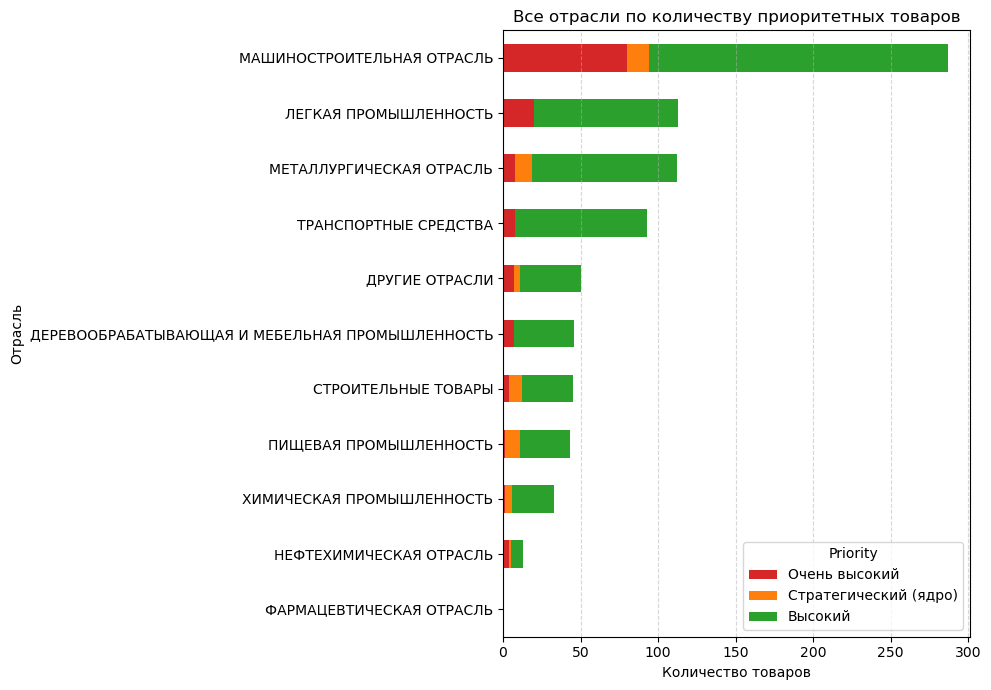

In [72]:
viz_df = priority_df.rename(columns={
    '🔴 Очень высокий': 'Очень высокий',
    '🔥 Стратегический (ядро)': 'Стратегический (ядро)',
    '🟠 Высокий': 'Высокий'
})

viz_df['Total_High'] = (
    viz_df['Очень высокий'] + 
    viz_df['Стратегический (ядро)'] + 
    viz_df['Высокий']
)

viz_df_sorted = viz_df.sort_values('Total_High', ascending=True)

viz_df_sorted[['Очень высокий', 'Стратегический (ядро)', 'Высокий']].plot(
    kind='barh', 
    stacked=True, 
    figsize=(10, 7),
    color=['#d62728', '#ff7f0e', '#2ca02c'],  # цвета по смыслу
    title="Все отрасли по количеству приоритетных товаров"
)

plt.xlabel("Количество товаров")
plt.ylabel("Отрасль")
plt.grid(True, axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()
